In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SequentialSampler, RandomSampler

from einops import rearrange
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

import os
from typing import List,Tuple,Dict

import sys

sys.path.append(os.path.abspath('../../ai4flow/acdm'))
sys.path.append(os.path.abspath('../../ai4flow'))

from turbpred.data_transformations import Transforms
from turbpred.model_diffusion import DiffusionModel
from turbpred.params import DataParams
from turbpred.model import PredictionModel
from turbpred.logger import Logger
from turbpred.params import DataParams, TrainingParams, LossParams, ModelParamsEncoder, ModelParamsDecoder, ModelParamsLatent
from turbpred.loss import PredictionLoss
from turbpred.loss_history import LossHistory
from turbpred.trainer_diffusion import TrainerDiffusion, TesterDiffusion


2024-05-24 14:34:41.076039: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-24 14:34:41.112414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-05-24 14:34:41.678215: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Data Handling and Loading

In [2]:
from dataset.airfoil_acdm import airfoilDataset
from dataset.airfoil_acdm import Transforms
self_cond = True

trainSet = airfoilDataset(name="V2D dataset",
                     dataDir="/home/chunyang/projects/DDPM4Science/data/airfoil_stable/train_6k",
                     sequenceLength=[3, 2], rey=1, self_cond=self_cond)

trainSet[0];

Loading data from 	 /home/chunyang/projects/DDPM4Science/data/airfoil_stable/train_6k
Loading completed. Files loaded: 	6400
Dataset info detail:
	 Sequence length of each sample: 3
	 Sequence skiping samples of: 2


In [3]:
idx = 99
data_raw = trainSet[idx]
mask = data_raw["obsMask"]
data = data_raw["data"]
print(data.shape)

(3, 6, 128, 64)


(128, 64)
/home/chunyang/projects/DDPM4Science/data/airfoil_stable/train_6k/ah6407_4167_-1122.npz


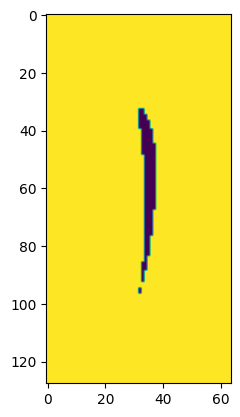

In [4]:
idx = 222
print(trainSet[idx]["obsMask"].shape)
print(trainSet[idx]["path"])
plt.imshow(trainSet[idx]["obsMask"])

(128, 64)
/home/chunyang/projects/DDPM4Science/data/airfoil_stable/train_6k/ah6407_4167_-1122.npz


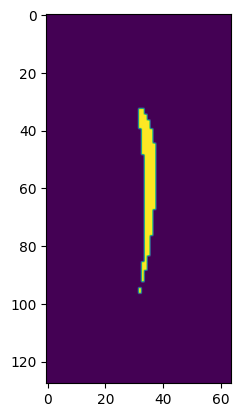

In [5]:
idx = 222
print(trainSet[idx]["obsMask"].shape)
print(trainSet[idx]["path"])
plt.imshow(trainSet[idx]["data"][1, 5, :, :])

## Training

With all these building blocks out of the way, now its time put them together and train the diffusion model. You can choose to either continue training for a few epochs from the provided model checkpoint (takes less than a minute for 10 epochs), or train the model from scratch on the small examplary data set (takes about half an hour for 1000 epochs). Note that the prediction quality and diversity for training the model from scratch will be noticeably worse, due to limited amount of data available here.

Feel free to skip this step entirely, if you don't want to train the network. You can directly continue with the sampling below, by using the pre-trained checkpoint.

In [6]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Training device: %s" % device)

p_d = DataParams(batch=32, augmentations=["normalize"], sequenceLength=[3,2], randSeqOffset=True,
            dataSize=[128,64], dimension=2, simFields=["pres"], simParams=["rey", "u_x", "u_y"], normalizeMode="incMixed")

# trainSet = TurbulenceDataset("Training", ["data"], filterTop=["128_inc"], filterSim=[(10,81)], filterFrame=[(800,1300)],
#                 sequenceLength=[p_d.sequenceLength], randSeqOffset=p_d.randSeqOffset, simFields=p_d.simFields, simParams=p_d.simParams, printLevel="sim")


transTrain = Transforms()
trainSet.transform = transTrain

trainSet.printDatasetInfo()
trainSampler = RandomSampler(trainSet)
#trainSampler = SequentialSampler(trainSet)
trainLoader = DataLoader(trainSet, sampler=trainSampler,
                    batch_size=p_d.batch, drop_last=True, num_workers=4)


Training device: cuda:0
Dataset info detail:
	 Sequence length of each sample: 3
	 Sequence skiping samples of: 2


In [7]:
trainSet[1]["data"].shape

torch.Size([3, 6, 128, 64])

In [8]:
trainSet[1].keys()

dict_keys(['data', 'simParameters', 'allParameters', 'path', 'obsMask'])

In [9]:
trainSet[1]["simParameters"]

array([[1.],
       [1.],
       [1.]], dtype=float32)

In [10]:
trainSet[1]["allParameters"]

{'Reynolds Number': array([1., 1., 1.], dtype=float32),
 'Mach Number': array([0., 0., 0.], dtype=float32),
 'Drag Coefficient': array([0., 0., 0.], dtype=float32),
 'Lift Coefficient': array([0., 0., 0.], dtype=float32),
 'Z Slice': array([0., 0., 0.], dtype=float32)}

In [11]:
trainSet[1]["path"]

'/home/chunyang/projects/DDPM4Science/data/airfoil_stable/train_6k/2032c_4984_1260.npz'

In [12]:
trainSet[1]["obsMask"].shape

torch.Size([128, 64])

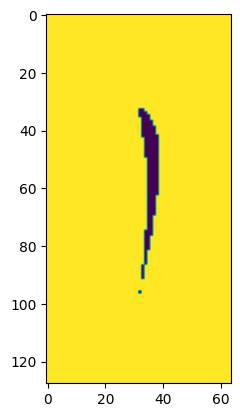

In [13]:
plt.imshow(trainSet[1]["obsMask"])

seq:  0


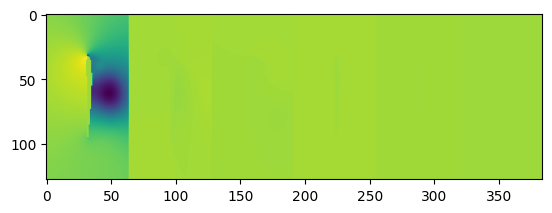

seq:  1


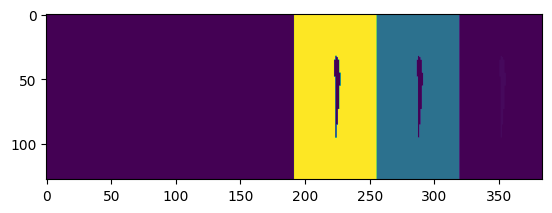

seq:  2


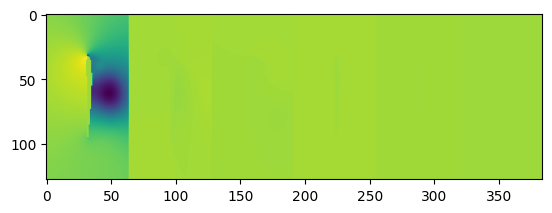

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [14]:
idx = 20
d = trainSet[idx]["data"]

for i in range(d.shape[0]):
    print("seq: ", i)
    plt.imshow(rearrange(d[i], "c h w -> h (c w)"))
    plt.show()

# torch.allclose(d[0, -1, :, :], torch.tensor(0.))
print(d[0, -1, :, :])

In [15]:
!pwd

/data_sdc/wcy/DDPM4Science/notebook/acdm_foil


In [16]:
startFromCheckpoint = False
useGPU = True
gpuID = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = gpuID

# pretrainPath = "/home/chunyang/projects/autoreg-pde-diffusion/models/models_inc/128_acdm-r20_00/Model.pth"
pretrainPath = ""


p_l = LossParams()
p_me = None
p_md = ModelParamsDecoder(arch="direct-ddpm+Prev", diffSteps=20, diffSchedule="linear", diffCondIntegration="noisy", trainingNoise=0.0)
p_ml = None
if startFromCheckpoint:
    p_t = TrainingParams(epochs=3, lr=0.001)
else:
    p_t = TrainingParams(epochs=3100, lr=0.0001)

model = PredictionModel(p_d, p_t, p_l, p_me, p_md, p_ml,
                        pretrainPath="" if not startFromCheckpoint else pretrainPath,
                        useGPU=useGPU)
model.printModelInfo()

12
in, out 18 84
Weights Trainable (All): 7006770 (7006770)      Dec: 7006770 (7006770)   
PredictionModel(
  (modelDecoder): DiffusionModel(
    (unet): Unet(
      (init_conv): Conv2d(18, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
      (time_mlp): Sequential(
        (0): SinusoidalPositionEmbeddings()
        (1): Linear(in_features=128, out_features=512, bias=True)
        (2): GELU(approximate='none')
        (3): Linear(in_features=512, out_features=512, bias=True)
      )
      (downs): ModuleList(
        (0): ModuleList(
          (0): ConvNextBlock(
            (mlp): Sequential(
              (0): GELU(approximate='none')
              (1): Linear(in_features=512, out_features=84, bias=True)
            )
            (ds_conv): Conv2d(84, 84, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=84)
            (net): Sequential(
              (0): GroupNorm(1, 84, eps=1e-05, affine=True)
              (1): Conv2d(84, 128, kernel_size=(3, 3), stride=(1, 1), 

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=p_t.lr, weight_decay=p_t.weightDecay)
logger = Logger("ACDM", addNumber=True)
logger.setup(model, optimizer)
trainHistory = LossHistory("_train", "Training", logger.tfWriter, len(trainLoader),
                                    0, 1, printInterval=1, logInterval=1, simFields=p_d.simFields)


trainer = TrainerDiffusion(model, trainLoader, optimizer, trainHistory, logger.tfWriter, p_t)

print('Starting Training')
logger.saveTrainState(0)


for epoch in range(0, p_t.epochs):
    trainer.trainingStep(epoch)
    logger.saveTrainState(epoch)

    trainHistory.updateAccuracy([p_d,p_t,p_l,p_me,p_md,p_ml], [], epoch==p_t.epochs-1)


Starting Training


/home/chunyang/miniconda3/envs/ai4flow/lib/python3.10/site-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[ 1,    1] (0.02 min): 1.1087
[ 1,    2] (0.02 min): 0.8143
[ 1,    3] (0.03 min): 0.7431
[ 1,    4] (0.03 min): 0.8431
[ 1,    5] (0.04 min): 0.6574
[ 1,    6] (0.04 min): 0.8211
[ 1,    7] (0.05 min): 0.5437
[ 1,    8] (0.05 min): 0.5133
[ 1,    9] (0.05 min): 0.5935
[ 1,   10] (0.06 min): 0.5998
[ 1,   11] (0.06 min): 0.6683
[ 1,   12] (0.07 min): 0.5035
[ 1,   13] (0.07 min): 0.5958
[ 1,   14] (0.08 min): 0.6517
[ 1,   15] (0.08 min): 0.5283
[ 1,   16] (0.09 min): 0.5014
[ 1,   17] (0.09 min): 0.4885
[ 1,   18] (0.10 min): 0.4915
[ 1,   19] (0.10 min): 0.5216
[ 1,   20] (0.11 min): 0.5079
[ 1,   21] (0.11 min): 0.4915
[ 1,   22] (0.12 min): 0.4834
[ 1,   23] (0.12 min): 0.4763
[ 1,   24] (0.13 min): 0.4892
[ 1,   25] (0.13 min): 0.4799
[ 1,   26] (0.14 min): 0.4787
[ 1,   27] (0.14 min): 0.4714
[ 1,   28] (0.15 min): 0.4822
[ 1,   29] (0.15 min): 0.4606
[ 1,   30] (0.15 min): 0.4550
[ 1,   31] (0.16 min): 0.4737
[ 1,   32] (0.16 min): 0.4607
[ 1,   33] (0.17 min): 0.4597
[ 1,   34]

KeyboardInterrupt: 

## Inference


In [18]:
# get: 1. testSet, testTransformer, testSampler and testLoader.
dataTransformationFieldIndices = [0,1,3,4]

# testSet = TurbulenceDataset("Test Low Reynolds 100-200", ["data"], filterTop=["128_inc"], filterSim=[[0, 82,84,86,88,90]],
#                 filterFrame=[(1000,1150)], sequenceLength=[[60,2]], simFields=["pres"], simParams=["rey"], printLevel="sim")
# testSet = V2dDataset(name="V2D dataset",
#                      dataDir="/home/chunyang/projects/autoreg-pde-diffusion/data/v2d/",
#                      idx_range=[90888, 91488],
#                      sequenceLength=[300, 2], rey=1)

testSet = airfoilDataset(name="V2D dataset",
                     dataDir="/home/chunyang/projects/DDPM4Science/data/airfoil_stable/test",
                     sequenceLength=[3, 2], rey=1, self_cond=self_cond)

testTransformations = Transforms()

testSet.transform = testTransformations

testSampler = SequentialSampler(testSet)
testLoader = DataLoader(testSet, sampler=testSampler, batch_size=len(testSet), drop_last=False)


Loading data from 	 /home/chunyang/projects/DDPM4Science/data/airfoil_stable/test
Loading completed. Files loaded: 	90
Dataset info detail:
	 Sequence length of each sample: 3
	 Sequence skiping samples of: 2


In [19]:
testSet.__len__()

90

In [20]:
testSet[0]["path"]

'/home/chunyang/projects/DDPM4Science/data/airfoil_stable/test/ag09_2028_-174.npz'

In [21]:
testSet[0].keys()

dict_keys(['data', 'simParameters', 'allParameters', 'path', 'obsMask'])

In [22]:
model.save(basePath="./")

Saving model to ./


In [23]:
# sample for dataset and model inference
# if startFromCheckpoint:
#     model = PredictionModel.load("/home/chunyang/projects/autoreg-pde-diffusion/runs/2D_Inc/128_acdm-r20_ours_01/Model.pth", useGPU=True)
model.eval()
model.to(device)

evalOptions = {"numEvals": 1,
    "sequentialEvalRuns": {"lowRey": True, "highRey": True, "varReyIn": True},
    "samplingMode": "ddpm",
    "posteriorSampling": "random",
    "initialSampling": "random",
    "conditioningIntegration": "noisy"
},

if isinstance(model.modelDecoder, DiffusionModel):
    if "samplingMode" in evalOptions:
        model.modelDecoder.inferenceSamplingMode = evalOptions["samplingMode"]
    if "posteriorSampling" in evalOptions:
        model.modelDecoder.inferencePosteriorSampling = evalOptions["posteriorSampling"]
    if "initialSampling" in evalOptions:
        model.modelDecoder.inferenceInitialSampling = evalOptions["initialSampling"]
    if "conditioningIntegration" in evalOptions:
        model.modelDecoder.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

elif isinstance(model.modelDecoder, torch.nn.ModuleList):
    for module in model.modelDecoder:
        if isinstance(module, DiffusionModel):
            if "samplingMode" in evalOptions:
                module.inferenceSamplingMode = evalOptions["samplingMode"]
            if "posteriorSampling" in evalOptions:
                module.inferencePosteriorSampling = evalOptions["posteriorSampling"]
            if "initialSampling" in evalOptions:
                module.inferenceInitialSampling = evalOptions["initialSampling"]
            if "conditioningIntegration" in evalOptions:
                module.inferenceConditioningIntegration = evalOptions["conditioningIntegration"]

with torch.no_grad():
    predSamples = []
    for s, sample in enumerate(testLoader, 0):
        data = sample["data"].to(device)
        simParameters = sample["simParameters"].to(device) if type(sample["simParameters"]) is not dict else None
        prediction, _, _ = model(data, simParameters)
        # print("jijiji", data.shape, prediction.shape)
        print("prediction shape before double unsqueeze: ", prediction.shape)
        prediction = prediction.unsqueeze(0).unsqueeze(0)
        print("prediction shape after double unsqueeze: ", prediction.shape)
        predSamples += [prediction.cpu().numpy()]

    predSamples = np.concatenate(predSamples, axis=2)
    print("sampling finished")


d here torch.Size([90, 3, 6, 128, 64])
d here torch.Size([90, 3, 6, 128, 64])
prediction shape before double unsqueeze:  torch.Size([90, 3, 6, 128, 64])
prediction shape after double unsqueeze:  torch.Size([1, 1, 90, 3, 6, 128, 64])
sampling finished


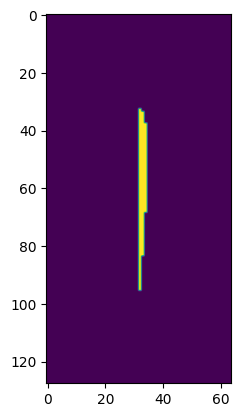

In [24]:
idx = 0
plt.imshow(predSamples[0][0, 0, idx, 5, :, :])

## Prediction Visualizations

After the sampling, we can analyze the ground truth flow trajectory and the samples generated by ACDM. Let's start with a direct visualization of the predictions.

In [25]:
print(predSamples[0].shape)
print(testSet[0]["data"].shape)

(1, 90, 3, 6, 128, 64)
torch.Size([3, 6, 128, 64])


In [26]:
def plot_col(axs, col_idx, tar_idx, data):
    """
    data should be of shape (3, 6, 128, 64)
    """
    for i in range(6):
        axs[i][col_idx].axis("off")
        axs[i][col_idx].imshow(data[tar_idx, i, :, :].T)

In [27]:
type(predSamples)

numpy.ndarray

torch.Size([1, 6, 128, 64])
True


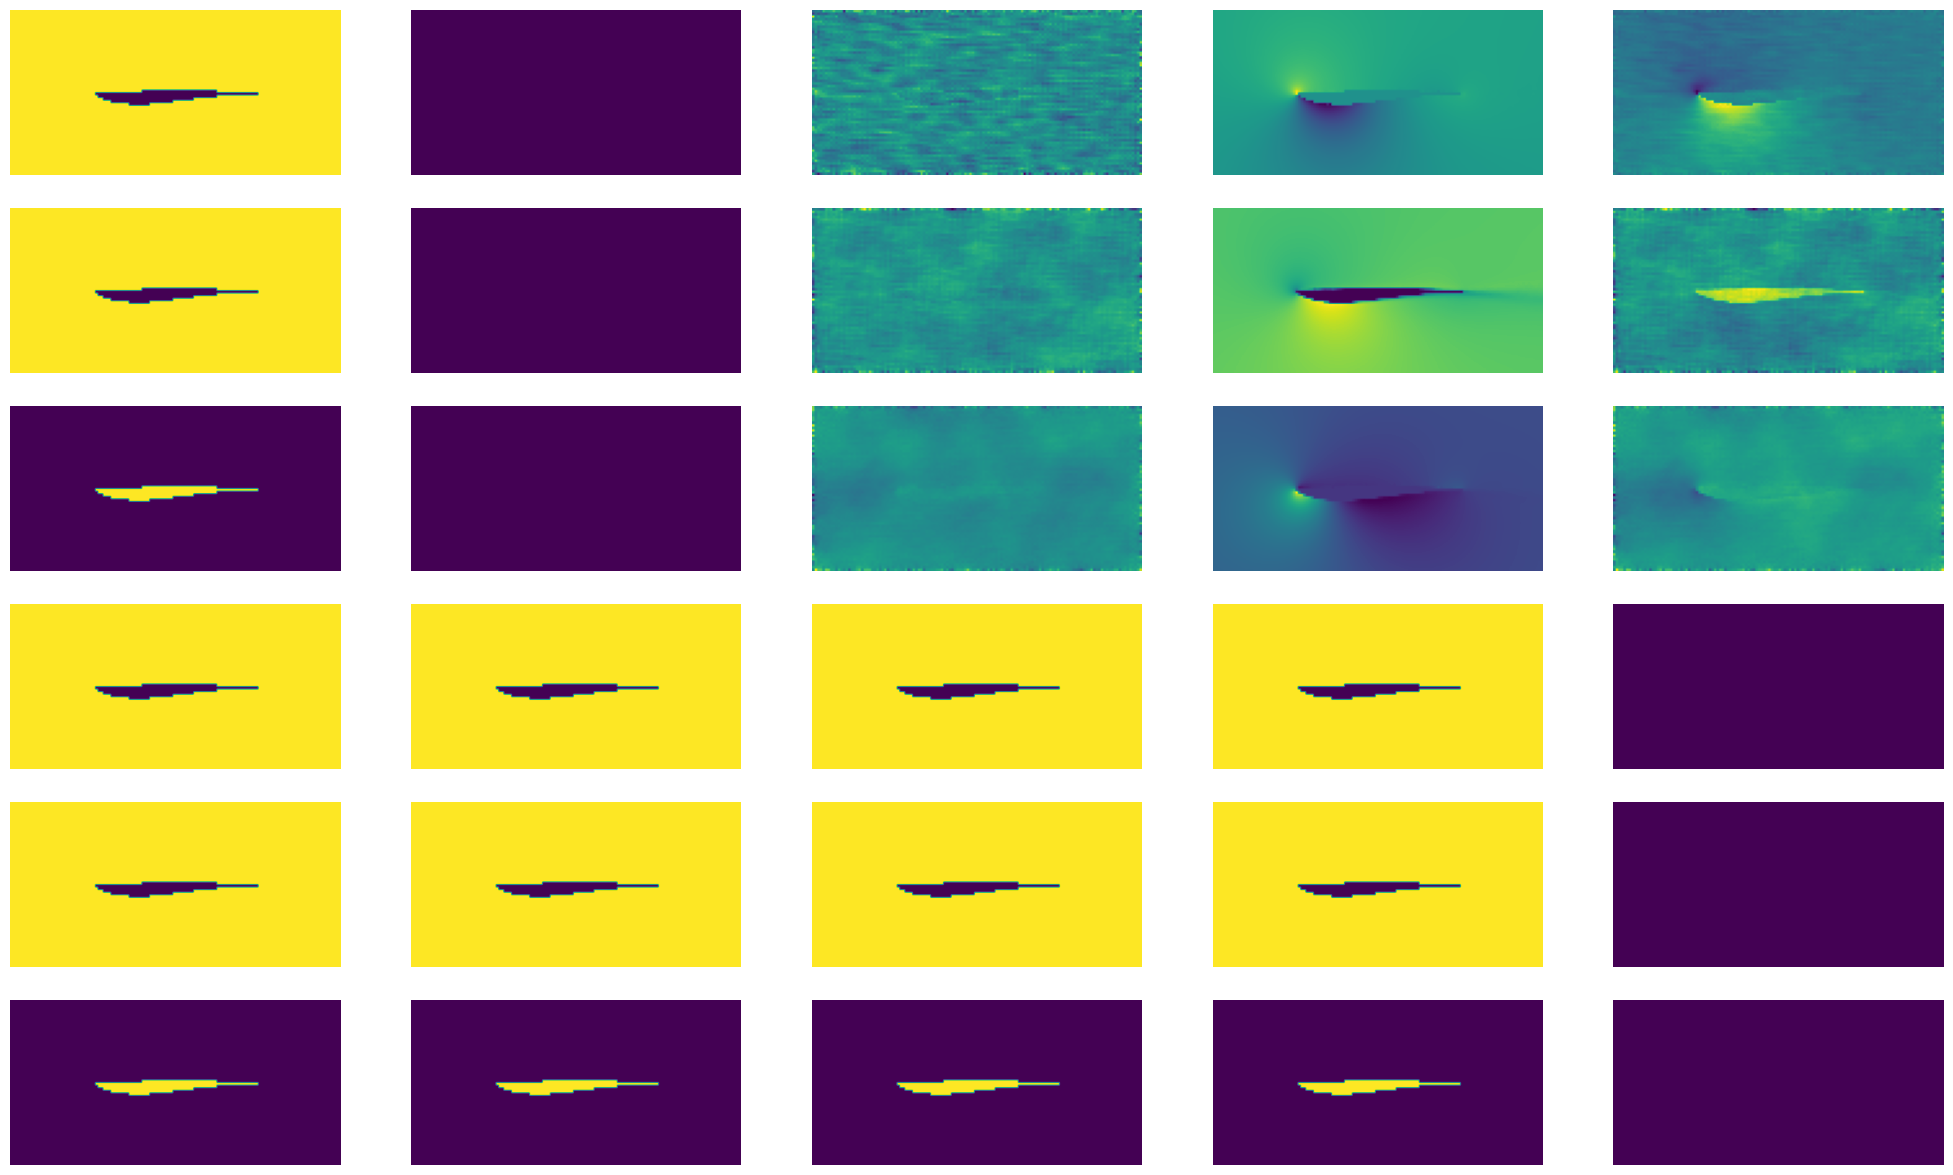

In [28]:
idx = 33

pred = torch.from_numpy(predSamples[0][0, idx, -1, :, :, :])
ground = testSet[idx]["data"][-1, :, :, :]
diff = (pred - ground).unsqueeze(dim=0)
print(diff.shape)
print(torch.allclose(pred[-3:, :, :], ground[-3:, :, :]))

fig, axs = plt.subplots(6, 5, figsize=(25, 15))

# plot the input / predicted data
for i in range(3):
    plot_col(axs, i, i, predSamples[0][0, idx, :, :, :])
# plot ground truth
plot_col(axs, 3, 2, testSet[idx]["data"])
plot_col(axs, 4, 0, diff)